# Voltage module walkthrough

This notebook demonstrates a compact end-to-end `setigen.voltage` workflow:

- build a synthetic dual-polarization antenna source
- inspect time-domain voltage samples
- record a small synthetic GUPPI RAW file
- reduce the first RAW block to a fine-channelized spectrogram
- confirm that the injected signals appear in the final spectrogram


In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import setigen as stg

output_dir = Path.cwd() / "generated"
output_dir.mkdir(parents=True, exist_ok=True)
output_dir


PosixPath('/Users/bryanbrzycki/Code/seti/setigen_development/stg-78_voltage_signal_walkthrough/generated')

In [10]:
sample_rate = 3e9 * u.Hz
num_taps = 8
num_branches = 1024
num_chans = 64
num_pols = 2

antenna = stg.voltage.Antenna(sample_rate=sample_rate,
                              fch1=6000e6 * u.Hz,
                              ascending=True,
                              num_pols=num_pols)

for stream in antenna.streams:
    stream.add_noise(v_mean=0, v_std=1)

antenna.x.add_constant_signal(f_start=6002.20e6 * u.Hz,
                              drift_rate=-2 * u.Hz / u.s,
                              level=0.010,
                              phase=0)
antenna.y.add_constant_signal(f_start=6002.20e6 * u.Hz,
                              drift_rate=-2 * u.Hz / u.s,
                              level=0.010,
                              phase=np.pi / 4)

antenna.x.add_constant_signal(f_start=6002.65e6 * u.Hz,
                              drift_rate=0 * u.Hz / u.s,
                              level=0.006,
                              phase=np.pi / 3)
antenna.y.add_constant_signal(f_start=6002.65e6 * u.Hz,
                              drift_rate=0 * u.Hz / u.s,
                              level=0.006,
                              phase=np.pi / 2)

digitizer = stg.voltage.RealQuantizer(target_fwhm=32, num_bits=8)
filterbank = stg.voltage.PolyphaseFilterbank(num_taps=num_taps,
                                             num_branches=num_branches)
requantizer = stg.voltage.ComplexQuantizer(target_fwhm=32, num_bits=8)

fftlength = 256
int_factor = 1
tchans_per_block = 16
block_size = stg.voltage.get_block_size(num_antennas=1,
                                        tchans_per_block=tchans_per_block,
                                        num_bits=requantizer.num_bits,
                                        num_pols=num_pols,
                                        num_branches=num_branches,
                                        num_chans=num_chans,
                                        fftlength=fftlength,
                                        int_factor=int_factor)
rvb = stg.voltage.RawVoltageBackend(antenna,
                                    digitizer=digitizer,
                                    filterbank=filterbank,
                                    requantizer=requantizer,
                                    start_chan=0,
                                    num_chans=num_chans,
                                    block_size=block_size,
                                    blocks_per_file=16,
                                    num_subblocks=32)

block_size, rvb.time_per_block


(1048576, np.float64(0.0013981013333333333))

## Inspect raw voltage samples

This preview uses the antenna data streams directly, before recording to RAW format.

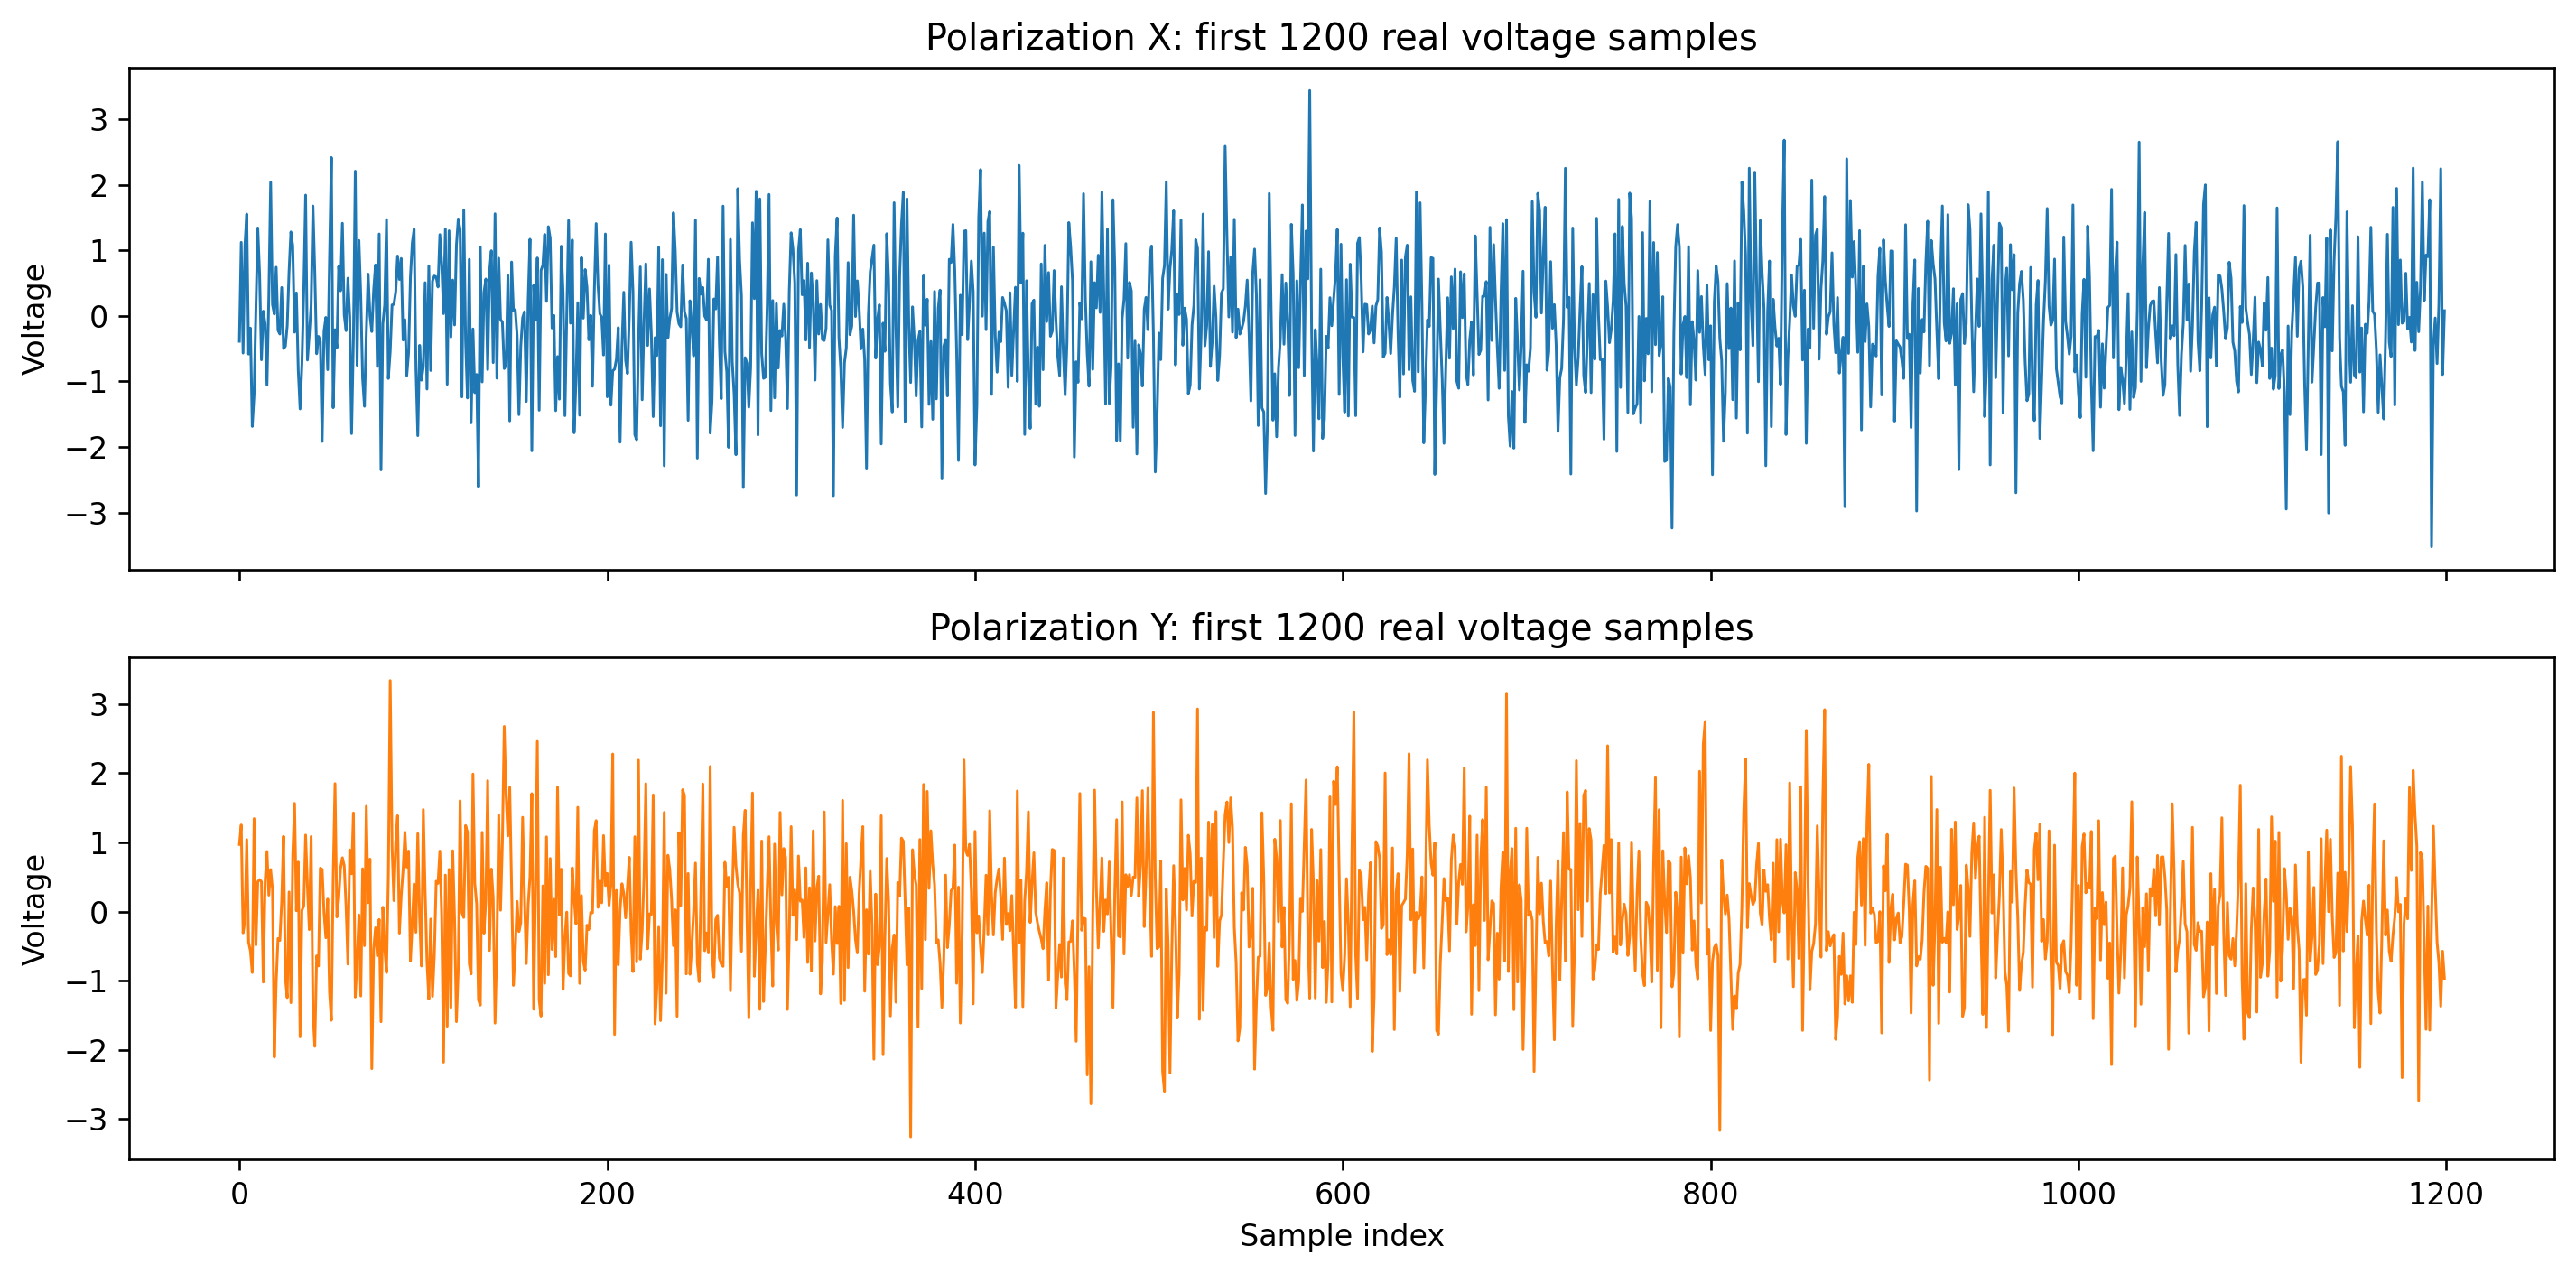

In [11]:
num_preview_samples = 4096
x_preview = antenna.x.get_samples(num_preview_samples)
y_preview = antenna.y.get_samples(num_preview_samples)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(x_preview[:1200], lw=0.9)
axes[0].set_title("Polarization X: first 1200 real voltage samples")
axes[0].set_ylabel("Voltage")

axes[1].plot(y_preview[:1200], lw=0.9, color="tab:orange")
axes[1].set_title("Polarization Y: first 1200 real voltage samples")
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Voltage")

plt.tight_layout()
plt.show()


## Record a compact synthetic RAW example

The backend resets the antenna timing internally before recording, so the time-domain preview above does not disturb the recorded output.

In [12]:
raw_stem = output_dir / "voltage_demo"
raw_path = output_dir / "voltage_demo.0000.raw"

rvb.record(output_file_stem=raw_stem,
           num_blocks=4,
           length_mode="num_blocks",
           header_dict={"HELLO": "voltage_walkthrough", "TELESCOP": "GBT"},
           verbose=False)

header = stg.voltage.read_header(raw_path)
raw_params = stg.voltage.get_raw_params(raw_stem)

print(raw_path)
print({key: header[key] for key in ["TELESCOP", "OBSNCHAN", "BLOCSIZE", "TBIN", "OBSFREQ"]})
raw_params


Blocks: 100%|██████████| 4/4 [00:01<00:00,  2.80it/s]

/Users/bryanbrzycki/Code/seti/setigen_development/stg-78_voltage_signal_walkthrough/generated/voltage_demo.0000.raw
{'TELESCOP': 'GBT     ', 'OBSNCHAN': '64', 'BLOCSIZE': '1048576', 'TBIN': '3.41333333333333E-07', 'OBSFREQ': '6092.28515625'}


{'num_bits': 8,
 'chan_bw': 2929687.5,
 'ascending': True,
 'num_pols': 2,
 'block_size': 1048576,
 'obs_length': 0.005592405333333333,
 'tbin': 3.41333333333333e-07,
 'num_antennas': 1,
 'num_chans': 64,
 'center_freq': 6092285156.25,
 'fch1': 6000000000.0}

## Fine-channelize the first RAW block into a spectrogram

`get_waterfall_from_raw()` is a lightweight helper for inspecting the first RAW block. It is enough for a quick visual check that the injected signals survive the voltage pipeline.

In [13]:
waterfall = stg.voltage.get_waterfall_from_raw(str(raw_path),
                                               block_size=rvb.block_size,
                                               num_chans=rvb.num_chans,
                                               fftlength=fftlength,
                                               int_factor=int_factor)
waterfall_db = 10 * np.log10(waterfall + 1e-12)
waterfall_db.shape


(16, 64)

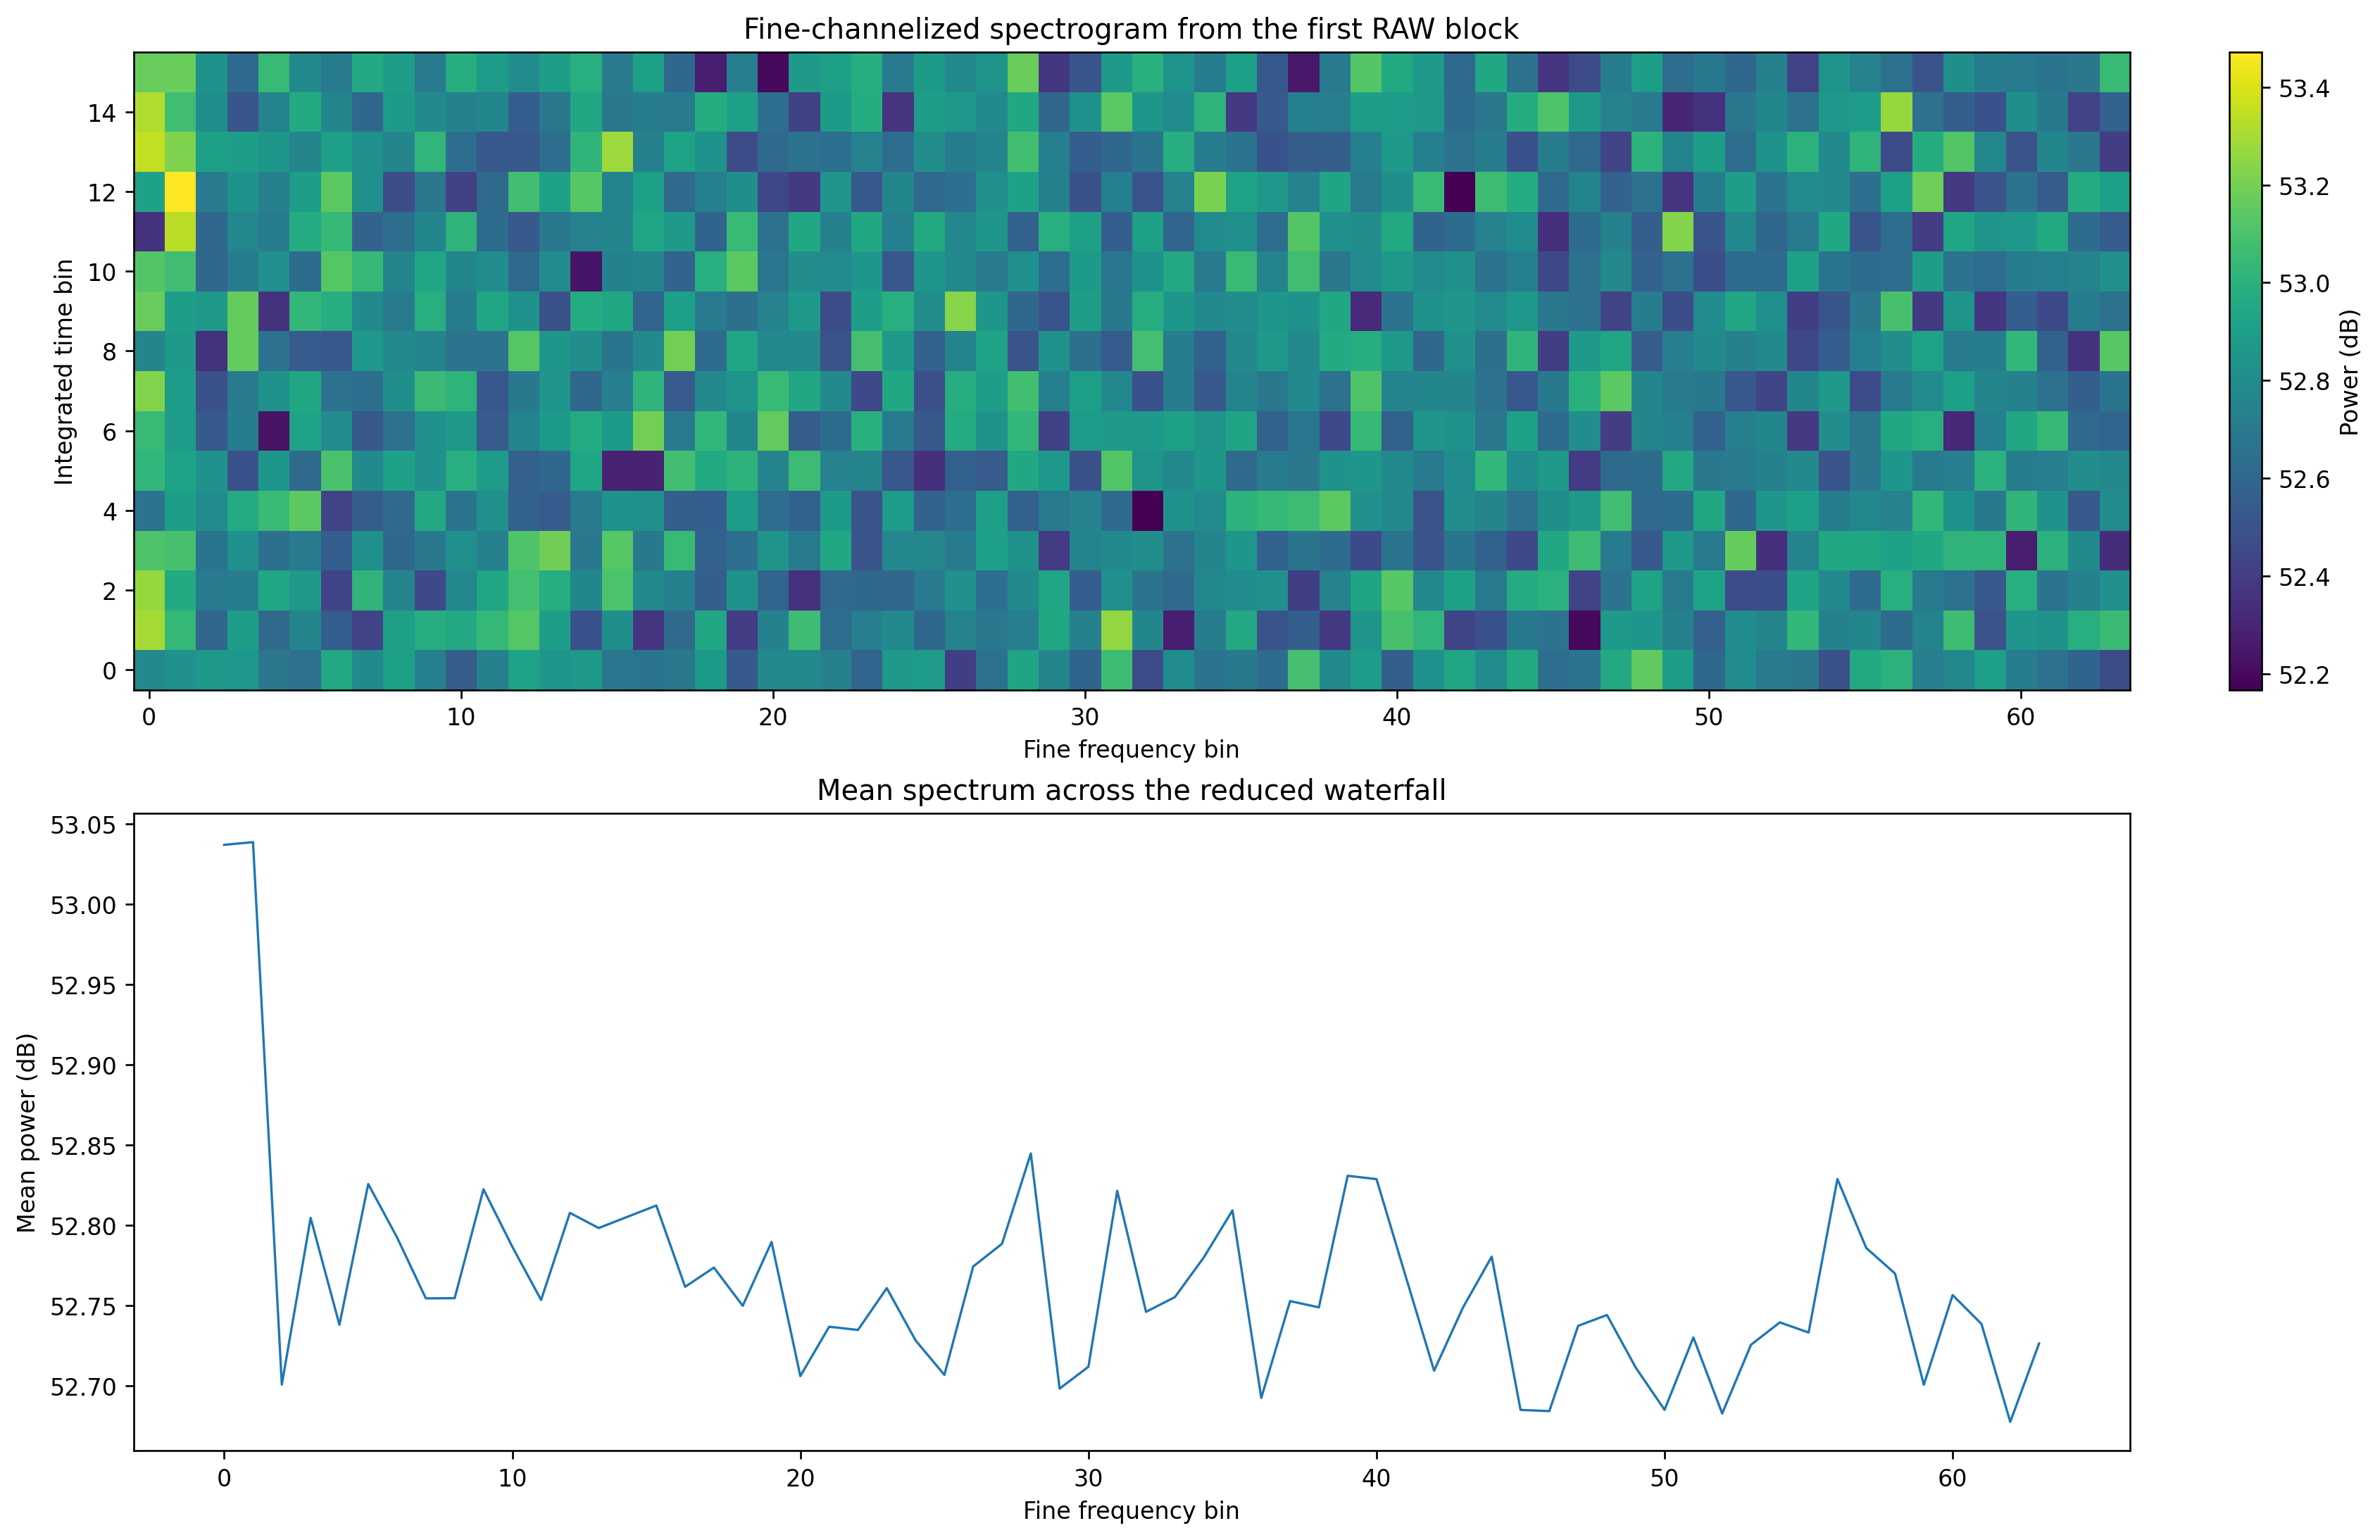

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)

im = axes[0].imshow(waterfall_db,
                    aspect="auto",
                    origin="lower",
                    interpolation="nearest")
axes[0].set_title("Fine-channelized spectrogram from the first RAW block")
axes[0].set_ylabel("Integrated time bin")
axes[0].set_xlabel("Fine frequency bin")
fig.colorbar(im, ax=axes[0], label="Power (dB)")

axes[1].plot(waterfall_db.mean(axis=0), lw=1.0)
axes[1].set_title("Mean spectrum across the reduced waterfall")
axes[1].set_xlabel("Fine frequency bin")
axes[1].set_ylabel("Mean power (dB)")

plt.show()


## Notes

- The drifting line and the stationary line should both be visible in the spectrogram.
- This walkthrough uses a very small block size to keep the demo quick.
- For deeper voltage inspection, see the main `jupyter-notebooks/voltage/` tutorials in the `setigen` repository.